In [1]:
import numpy as np
from qutip import (
    sigmax, sigmay, sigmaz, 
    basis, qeye, tensor, 
    Qobj, Bloch, 
    ket2dm
    )

from quaccatoo import QSys, PulsedSim, Analysis, RabiModel, Rabi, NV

import matplotlib.pyplot as plt

In [2]:
# make a physical NV center object
B0 = 0
nv = NV(B0=B0, units_B0='mT', N = 14)

nv.rho0 = nv.rho0 / nv.rho0.tr()
nv.H0

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 2.86285e+03  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
   0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  2.87000e+03  0.00000e+00 -2.70000e+00  0.00000e+00
   0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  2.86713e+03  0.00000e+00 -2.70000e+00
   0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00 -2.70000e+00  0.00000e+00 -5.01000e+00  0.00000e+00
   0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00 -2.70000e+00  0.00000e+00  0.00000e+00
   0.00000e+00 -2.70000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
  -5.01000e+00  0.00000e+00 -2.70000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00 -2.70000e+00
   0.00000e+00  2.86713e+03  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.0

In [3]:
nv.rho0

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.33333333 0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.33333333 0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.33333333
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]]

the energy expectation value is -1.1133333333333333


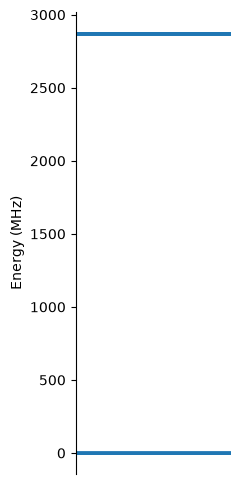

In [4]:
nv.plot_energy() # this is the nuclear spin

expec_energy = nv.rho0.dag() * nv.H0 * nv.rho0
print(f'the energy expectation value is {expec_energy.tr()}')

In [5]:
# truncate the m_I = +1 state
nv.truncate(mS=1)
nv.H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-5.01000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
   0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00 -2.70000e+00  0.00000e+00
   0.00000e+00]
 [ 0.00000e+00  0.00000e+00 -5.01000e+00  0.00000e+00 -2.70000e+00
   0.00000e+00]
 [ 0.00000e+00 -2.70000e+00  0.00000e+00  2.86713e+03  0.00000e+00
   0.00000e+00]
 [ 0.00000e+00  0.00000e+00 -2.70000e+00  0.00000e+00  2.87000e+03
   0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
   2.86285e+03]]

In [7]:
print("Microwave operator shape:", nv.MW_h1.shape)
print("RF operator shape:", nv.RF_h1.shape)

print("MW transition frequencies:", nv.MW_freqs)
print("RF transition frequencies:", nv.RF_freqs)

for index, energy_mhz in enumerate(nv.energy_levels):
    print(f"Level {index}: {energy_mhz:.6f} MHz")

Microwave operator shape: (6, 6)
RF operator shape: (6, 6)
MW transition frequencies: [2867.62005217 2872.39010433]
RF transition frequencies: [5.00745043 5.00745043 4.28       4.28       0.         2.86745043]
Level 0: 0.000000 MHz
Level 1: 0.002536 MHz
Level 2: 5.009993 MHz
Level 3: 2867.862536 MHz
Level 4: 2872.145078 MHz
Level 5: 2875.015071 MHz


## Simple physical microwave Rabi experiment

This section uses the already-created and truncated `nv` object as the physical quantum system. The static Hamiltonian, electron-nuclear hyperfine coupling, initial state, measurement operator, and microwave spin operator all come from `NV`; no replacement `QSys` Hamiltonian is constructed here.

At zero magnetic field, transitions involving $m_s=+1$ and $m_s=-1$ are degenerate before truncation. This is therefore an introductory control simulation rather than a hyperfine-selective implementation of the full tripod protocol.

In [8]:
# Microwave-control parameters. QuaCCAToo uses MHz and microseconds.
mw_rabi_mhz = 0.20
mw_frequency_mhz = float(nv.MW_freqs[0])
pulse_durations_us = np.linspace(0.0, 5.0, 501)

print(f"Drive frequency: {mw_frequency_mhz:.6f} MHz")
print(f"Microwave Rabi amplitude: {mw_rabi_mhz:.3f} MHz")

Drive frequency: 2867.620052 MHz
Microwave Rabi amplitude: 0.200 MHz


In [9]:
# Rabi uses nv.H0 for free evolution and nv.MW_h1 for the physical MW drive.
physical_nv_rabi = Rabi(
    pulse_duration=pulse_durations_us,
    system=nv,
    h1=mw_rabi_mhz * nv.MW_h1,
    pulse_params={
        "f_pulse": mw_frequency_mhz,
        "phi_t": 0.0,
    },
    options={
        "nsteps": 20000,
        "atol": 1e-9,
        "rtol": 1e-7,
    },
)

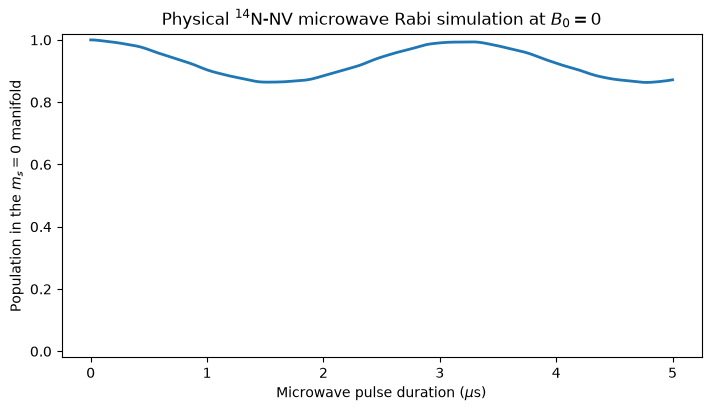

In [10]:
physical_nv_rabi.run()

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(
    physical_nv_rabi.variable,
    physical_nv_rabi.results,
    lw=2,
)
ax.set(
    xlabel=r"Microwave pulse duration ($\mu$s)",
    ylabel=r"Population in the $m_s=0$ manifold",
    title=r"Physical $^{14}$N-NV microwave Rabi simulation at $B_0=0$",
    ylim=(-0.02, 1.02),
)
plt.show()